# Predicting Businesses Closure- Building Dataset


Our goal was to build a classifier that would predict business will close or not based on the Yelp dataset. The motivation was to create a model that would give investors a chance to better asses the risk of bussiness failure and to provide them with information that would help them to make an informed decision whether they should invest in given business or not.   
   
   
This scripts performs data import, data visualization/exploration, feature extraction and preparation for classification. The classification process itself is implemented in script ***Run_Classification.ipnb***.   
      
THe Yelp Dataset is composed of several different dataframes: 
   
***Business***  basic Yelp information about the bussiness i.e. star rating, number of reviews, business's location etc.    
***Review*** individual reviews of the businesses with star rating, text...  
***Business Attributes*** detailed information about businesses (note: the dataset has many missing values)   
***Business Hours*** self explanatory  
***Check-in*** checkins on a business   
***Tips*** tips written by a user on a business   
***User***  metadata associated with the user

Disclaimer: Due to limited time for this project, I have restricted my analysis to 'bussiness' and 'review' dataframes. Also, not all features were fully utilized e.g. the geolocation information was not used for classication although it might have be potenially useful.   
      
Here, in this script, we used Python together with Pandas (https://pandas.pydata.org/) for dataframe processing and Seaborn library (https://seaborn.pydata.org/) for plotting figures. The review text sentiment analysis was done by VADER (https://github.com/cjhutto/vaderSentiment) and was implemented in **vader_sentence.py**.

### Table of contents:
[(1) Importing libraries and loading data](#1)    
[(2) Data Headers](#2)   
[(3) Business Dataframe Exploration](#3)   
[(4) Review Dataframe Exploration](#4)   
[(5) Review Sentiment Analysis](#5)   
[(6) Business Atribute Dataframe Exploration](#6)    
[(7) Data vs Target Outcomes](#7)  
[(8) Building Classification Features Matrix](#8)  
[(9) Summary](#9)   



## (1) Importing libraries and loading data <a class="anchor" id="1"></a>

In [1]:
# Import libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [215]:
# Load CSV data
business = pd.read_csv('yelp_business.csv')
business_attributes = pd.read_csv('yelp_business_attributes.csv')
business_hours = pd.read_csv('yelp_business_hours.csv', na_values='None')
checkin = pd.read_csv('yelp_checkin.csv')
review = pd.read_csv('yelp_review.csv')
tip = pd.read_csv('yelp_tip.csv')
user = pd.read_csv('yelp_user.csv')
review['date'] = pd.to_datetime(review['date']).reset_index(drop=True) # time in string to date_time

## (2) Data Headers <a class="anchor" id="2"></a>
Display dataframe headers from all the datasets

In [3]:
business.head(2)

,business_id,name,neighborhood,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,categories
0,FYWN1wneV18bWNgQjJ2GNg,"""Dental by Design""",NaN,"""4855 E Warner Rd, Ste B9""",Ahwatukee,AZ,85044,33.330690,-111.978599,4.0,22,1,Dentists;General Dentistry;Health & Medical;Or...
1,He-G7vWjzVUysIKrfNbPUQ,"""Stephen Szabo Salon""",NaN,"""3101 Washington Rd""",McMurray,PA,15317,40.291685,-80.104900,3.0,11,1,Hair Stylists;Hair Salons;Men's Hair Salons;Bl...


In [4]:
business_attributes.head(2)

,business_id,AcceptsInsurance,ByAppointmentOnly,BusinessAcceptsCreditCards,BusinessParking_garage,BusinessParking_street,BusinessParking_validated,BusinessParking_lot,BusinessParking_valet,HairSpecializesIn_coloring,...,Corkage,DietaryRestrictions_dairy-free,DietaryRestrictions_gluten-free,DietaryRestrictions_vegan,DietaryRestrictions_kosher,DietaryRestrictions_halal,DietaryRestrictions_soy-free,DietaryRestrictions_vegetarian,AgesAllowed,RestaurantsCounterService
0,FYWN1wneV18bWNgQjJ2GNg,Na,Na,Na,True,Na,Na,Na,Na,Na,...,Na,Na,Na,Na,Na,Na,Na,Na,Na,Na
1,He-G7vWjzVUysIKrfNbPUQ,Na,Na,Na,Na,Na,Na,Na,Na,Na,...,Na,Na,Na,Na,Na,Na,Na,Na,Na,Na


In [5]:
business_hours.head(2)

,business_id,monday,tuesday,wednesday,thursday,friday,saturday,sunday
0,FYWN1wneV18bWNgQjJ2GNg,7:30-17:0,7:30-17:0,7:30-17:0,7:30-17:0,7:30-17:0,NaN,NaN
1,He-G7vWjzVUysIKrfNbPUQ,9:0-20:0,9:0-20:0,9:0-20:0,9:0-20:0,9:0-16:0,8:0-16:0,NaN


In [6]:
checkin.head(2)

,business_id,weekday,hour,checkins
0,3Mc-LxcqeguOXOVT_2ZtCg,Tue,0:00,12
1,SVFx6_epO22bZTZnKwlX7g,Wed,0:00,4


In [7]:
review.head(2)

,review_id,user_id,business_id,stars,date,text,useful,funny,cool
0,vkVSCC7xljjrAI4UGfnKEQ,bv2nCi5Qv5vroFiqKGopiw,AEx2SYEUJmTxVVB18LlCwA,5,2016-05-28,Super simple place but amazing nonetheless. It...,0,0,0
1,n6QzIUObkYshz4dz2QRJTw,bv2nCi5Qv5vroFiqKGopiw,VR6GpWIda3SfvPC-lg9H3w,5,2016-05-28,Small unassuming place that changes their menu...,0,0,0


In [8]:
tip.head(2)

,text,date,likes,business_id,user_id
0,Great breakfast large portions and friendly wa...,2015-08-12,0,jH19V2I9fIslnNhDzPmdkA,ZcLKXikTHYOnYt5VYRO5sg
1,Nice place. Great staff. A fixture in the tow...,2014-06-20,0,dAa0hB2yrnHzVmsCkN4YvQ,oaYhjqBbh18ZhU0bpyzSuw


In [9]:
user.head(2)

,user_id,name,review_count,yelping_since,friends,useful,funny,cool,fans,elite,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,JJ-aSuM4pCFPdkfoZ34q0Q,Chris,10,2013-09-24,"0njfJmB-7n84DlIgUByCNw, rFn3Xe3RqHxRSxWOU19Gpg...",0,0,0,0,None,...,0,0,0,0,0,0,0,0,0,0
1,uUzsFQn_6cXDh6rPNGbIFA,Tiffy,1,2017-03-02,None,0,0,0,0,None,...,0,0,0,0,0,0,0,0,0,0


___

## (3) 'Business' dataframe exploration <a class="anchor" id="3"></a>

This dataframe contain basic Yelp information about the bussiness i.e. star rating, number of reviews, business's location etc.    

**Data description:**

    "business_id": character unique string business id
    "name": the business's name
    "neighborhood: the business's neigborhood
    "address": the full address of the business
    "city": the city
    "state": 2 character state code, if applicable
    "postal code": the postal code
    "latitude": latitude
    "longitude": longitude
    "stars": star rating, rounded to half-stars
    "review_count": number of reviews
    "is_open": 0 or 1 for closed or open, respectively
    "categories: the category of business

**Number of yelp reviews per business**

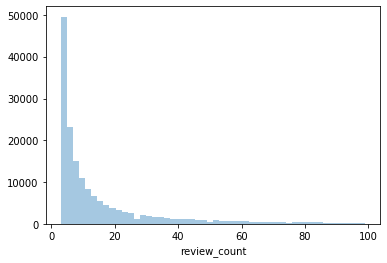

In [10]:
# number of reviews per business
sns.distplot(business[business['review_count']<100]['review_count'],kde=False);

Comment:
For future analysis ***keeping only business that have at least 10 reviews.*** This has been done as it is hard to make some reasonable judgment about the business when we don't have much information.

In [11]:
business=business[business['review_count']>=10]; # drop businesses with less then 10 reviews

**What are the types of businesses ?**

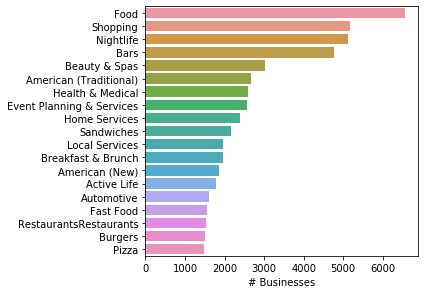

In [70]:
# What are the businesses
business_str=''.join(business['categories'])
categories_split=pd.DataFrame(business_str.split(';'),columns=['business_types']) # split string with multiple categories
categories_count=categories_split['business_types'].value_counts()
categories_split['business_types']
categories_count=categories_count[1:20];
sns.barplot(x=categories_count.values,y=categories_count.index)
plt.tight_layout()
plt.xlabel('# Businesses');

**What are the types of businesses-simplified categories ?**   

As the original data was spread across too many categories, we decided to keep only the top 20 most common categories and label businesses that don't belong to this group as 'other'.

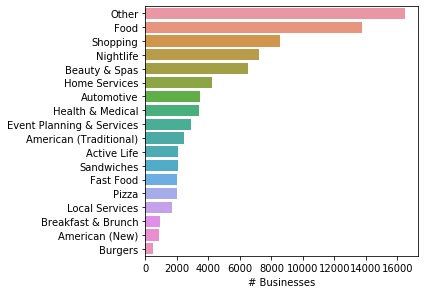

In [71]:
top_20_cat=categories_count[0:20].index
def simple_cat_func(cat_string):
    """Gets and prints the spreadsheet's header columns
    
    """    
    cat_list=cat_string.split(';') #separate individual categories from string
    for cat in top_20_cat: # if it has keywords corresponding to more than one category, label as the higher one in the top 10 list 
        if cat in cat_list:
            simple_cat=cat
            break
        else:
            simple_cat='Other'
    return simple_cat

categories_simplified=business['categories'].apply(lambda cat_string:  simple_cat_func(cat_string))
business['categories_simplified']=categories_simplified

categories_simplified_counts=categories_simplified.value_counts()
sns.barplot(x=categories_simplified_counts.values,y=categories_simplified_counts.index)
plt.tight_layout()
plt.xlabel('# Businesses');

**Distribution of average star rating**

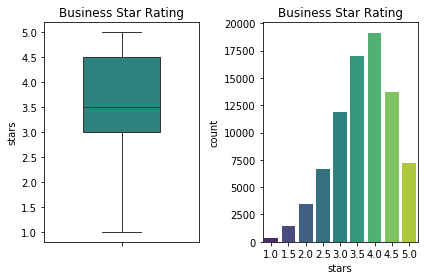

In [13]:
plt.subplot(1,2,1)
ax=sns.boxplot(y=business['stars'], palette='viridis', width=0.5,linewidth=1)
plt.title('Business Star Rating');
plt.tight_layout()

plt.subplot(1,2,2)
ax=sns.countplot(x='stars',data=business, palette='viridis')
plt.title('Business Star Rating');
plt.tight_layout()

**Ratio between open and closed businesses**

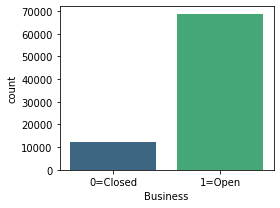

In [14]:
plt.figure(figsize=(4, 3))
ax=sns.countplot(x='is_open',data=business,palette='viridis')
plt.tight_layout()
ax.set_xticklabels(['0=Closed','1=Open']);
plt.xlabel('Business');
plt.tight_layout()

**Where are the businesses ?**

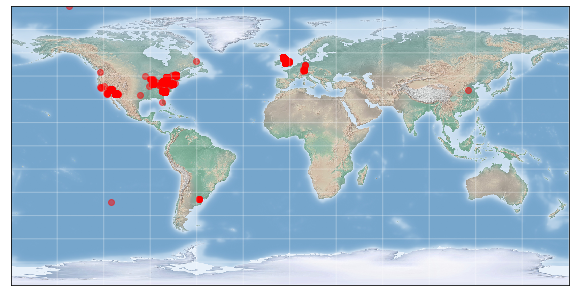

In [212]:
## For details see:
## https://jakevdp.github.io/PythonDataScienceHandbook/04.13-geographic-data-with-basemap.html
import os
os.environ['PROJ_LIB']='''C:/Users/ADA/Anaconda3/Library/share'''
from mpl_toolkits.basemap import Basemap
from itertools import chain

def draw_map(m, scale=0.2):
    # draw a shaded-relief image
    m.shadedrelief(scale=scale)    
    # lats and longs are returned as a dictionary
    lats = m.drawparallels(np.linspace(-90, 90, 13))
    lons = m.drawmeridians(np.linspace(-180, 180, 13))
    # keys contain the plt.Line2D instances
    lat_lines = chain(*(tup[1][0] for tup in lats.items()))
    lon_lines = chain(*(tup[1][0] for tup in lons.items()))
    all_lines = chain(lat_lines, lon_lines)    
    # cycle through these lines and set the desired style
    for line in all_lines:
        line.set(linestyle='-', alpha=0.3, color='w')       
       
plt.figure(figsize=(10, 7))
m = Basemap(projection='cyl', resolution=None,
            llcrnrlat=-90, urcrnrlat=90,
            llcrnrlon=-180, urcrnrlon=180, )
draw_map(m)
lat = business['latitude'].values
lon = business['longitude'].values
m.scatter(lon, lat, latlon=True,alpha=0.5,color='red');

Note: although this might be a very interesting feature for classification, we have ommited it due to the time-contraints of the project

## (4) 'Review' dataframe exploration <a class="anchor" id="4"></a>

This dataframe contain individual reviews of the businesses with star rating, text...   

Dataset features:   
  
    "review_id": character unique review id
    "user_id": character unique user id
    "business_id": character business id, maps to business in business
    "stars": integer, star rating
    "date": string, date formatted YYYY-MM-DD
    "text": string, the review itself
    "useful": number of useful votes received 
    "funny": number of funny votes received
    "cool": number of cool votes received

**Star-rating and number of reviews in time (derived measure from 'Review' dataframe)** 

The original bussiness dataframe only shows review rating and score averaged across time. This might be potentially sub-optimal for classification as the outcome might depend on time e.g. businesses that were good in the past might be recently bad, which could mean higher potential for closing. Here, we extracted several time-dependent features:   
   


In [16]:
## Add transform 'date' column into relative measure describing how many days elapsed since last review for each business
review['RelDate']=review.groupby('business_id')['date'].transform(lambda x: x-max(x)) 

# Input Params
days_to_past=720; # max days we look in the past
n_time_segs=4; # how many time segments we want

# Generate day selection indices 
from_day_lst=list(range(0,days_to_past,days_to_past//n_time_segs))
to_day_lst = [day+days_to_past//n_time_segs for day in from_day_lst]

# Calculate mean star rating and review count for each time-window
star_intime_df=pd.DataFrame()
revcount_intime_df=pd.DataFrame()
for i in range(0,n_time_segs):
    #display('Processing time-window: '+ str(i+1) +'/'+ str(n_time_segs))
    from_day=pd.Timedelta(-from_day_lst[i], unit='d')
    to_day=pd.Timedelta(-to_day_lst[i], unit='d')
    review_grouped=review[(review['RelDate']>to_day) & (review['RelDate']<=from_day)].groupby('business_id')
    review_intime=review_grouped['stars'].aggregate(['mean','count'])    
    star_intime_df[str(-from_day_lst[i])+':'+str(-to_day_lst[i])]=review_intime['mean'];
    revcount_intime_df[str(-from_day_lst[i])+':'+str(-to_day_lst[i])]=review_intime['count'];

star_intime_df.reset_index(inplace=True)
revcount_intime_df.reset_index(inplace=True)

**Plot average review score and review count over time**

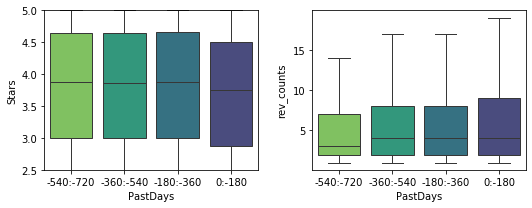

In [17]:
# Star rating vs days since last review
plt.figure(figsize=(7.5, 3))
plt.subplot(1,2,1)
star_intime_df_ext=pd.merge(star_intime_df,business[['is_open','business_id']],how='inner',on='business_id')
star_intime_df_ext_melt=star_intime_df_ext.melt(id_vars=['is_open','business_id'],var_name='PastDays',value_name='Stars')
sns.boxplot(x='PastDays',y='Stars',data=star_intime_df_ext_melt,palette='viridis',dodge=True,fliersize=1,linewidth=1)
plt.tight_layout()
plt.gca().invert_xaxis()
plt.ylim([2.5,5])
# Review vs days since last review
plt.subplot(1,2,2)
revcount_intime_df_ext=pd.merge(revcount_intime_df,business[['is_open','business_id']],how='inner',on='business_id')
revcount_intime_df_ext_melt=revcount_intime_df_ext.melt(id_vars=['is_open','business_id'],var_name='PastDays',value_name='rev_counts')
sns.boxplot(x='PastDays',y='rev_counts',data=revcount_intime_df_ext_melt,palette='viridis',dodge=True,showfliers=False,linewidth=1)
plt.tight_layout()
plt.gca().invert_xaxis()

<br>

## (5) Review Sentiment Analysis <a class="anchor" id="5"></a>

Besides score, the user review also contain text field, where users can write their opinion about the restaurant. Here, we analyzed the text reviews for sentiment i.e. it was determined whether a review is positive, neutral, negative. 

To perform this, I have used **VADER sentiment analysis tools**:  
Hutto, C. J., & Gilbert, E. (2014, May). Vader: A parsimonious rule-based model for sentiment analysis of social media text. In Eighth international AAAI conference on weblogs and social media.  This analysis was implemented in script **vader_sentence.py**
See:  
https://github.com/cjhutto/vaderSentiment#citation-information  
https://www.nltk.org/_modules/nltk/sentiment/vader.html

**Sentiment scoring attributes:**  
positive (pos) - proportions of text that is positive   
neutral (neu) - proportions of text that is neutral   
negative (neg) - proportions of text that is negative   
compound (comp) - normalized composite score 

**Compound score meaning:**    
positive sentiment: compound score >= 0.05  
neutral sentiment: (compound score > -0.05) and (compound score < 0.05)  
negative sentiment: compound score <= -0.05  





In [18]:
sentiment = pd.read_csv('vader_sentence_sentiment.csv') # load previously extracted sentiment values. See file vader_sentence.py
sentiment['business_id']=review['business_id'] # Add corresponding business_id 
sentiment['stars']=review['stars'] # Add corresponding business_id 
sentiment.drop(sentiment.columns[0],axis=1,inplace=True)
sentiment_grp=sentiment.groupby('business_id').aggregate('mean').reset_index()
sentiment_grp=pd.merge(sentiment_grp,business[['is_open','business_id']],how='inner',on='business_id')
sentiment_grp.head()

,business_id,neg_avg,neu_avg,pos_avg,comp_avg,neg_max,neu_max,pos_max,comp_max,stars,is_open
0,--6MefnULPED_I942VcFNA,0.039908,0.817213,0.142859,0.213005,0.051351,0.651838,0.296811,0.573657,3.135135,1
1,--7zmmkVg-IMGaXbuVd0SQ,0.038021,0.712088,0.235542,0.326991,0.034936,0.564064,0.401021,0.618085,3.851064,1
2,--9QQLMTbFzLJ_oT-ON3Xw,0.064936,0.754352,0.180684,0.188558,0.057000,0.550273,0.392727,0.541464,3.363636,1
3,--9e1ONYQuAa-CB_Rrw7Tw,0.035367,0.744806,0.216046,0.307312,0.032758,0.582294,0.384952,0.675897,4.088904,1
4,--DaPTJW3-tB1vP-PfdTEg,0.029272,0.719376,0.246204,0.339775,0.027974,0.586436,0.385564,0.607862,3.666667,1


**Mean review sentiment (averaged across sentences in review)**

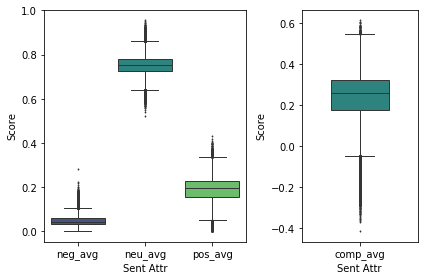

In [19]:
sel_col=[0]+list(range(1,5))+[9, 10]  # Select colums for averaged sentiment
sentiment_avg_melt=sentiment_grp.iloc[:,sel_col].melt(id_vars=['is_open','business_id','stars'],var_name='Sent Attr',value_name='Score')

from matplotlib import gridspec
gs = gridspec.GridSpec(1, 5)
plt.subplot(gs[0:3])
ax=sns.boxplot(x='Sent Attr',y='Score',data=sentiment_avg_melt[sentiment_avg_melt['Sent Attr']!='comp_avg'], palette='viridis',dodge=True,fliersize=1,linewidth=1)
plt.tight_layout()
plt.subplot(gs[3:6])
ax=sns.boxplot(x='Sent Attr',y='Score',data=sentiment_avg_melt[sentiment_avg_melt['Sent Attr']=='comp_avg'], palette='viridis',dodge=True,fliersize=1,linewidth=1,width=0.5)
plt.tight_layout()

**Max review sentiment (based on sentence in review with highest coumpound score)**

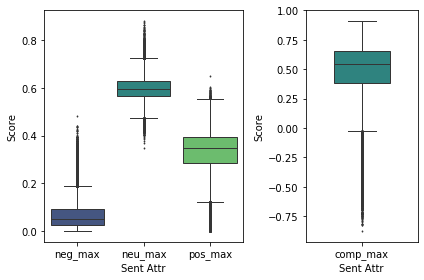

In [20]:
sel_col=[0]+list(range(5,9))+[9, 10]  # Select colums for max sentiment
sentiment_max_melt=sentiment_grp.iloc[:,sel_col].melt(id_vars=['is_open','business_id','stars'],var_name='Sent Attr',value_name='Score')

from matplotlib import gridspec
gs = gridspec.GridSpec(1, 5)
plt.subplot(gs[0:3])
ax=sns.boxplot(x='Sent Attr',y='Score',data=sentiment_max_melt[sentiment_max_melt['Sent Attr']!='comp_max'], palette='viridis',dodge=True,fliersize=1,linewidth=1)
plt.tight_layout()
plt.subplot(gs[3:6])
ax=sns.boxplot(x='Sent Attr',y='Score',data=sentiment_max_melt[sentiment_max_melt['Sent Attr']=='comp_max'], palette='viridis',dodge=True,fliersize=1,linewidth=1,width=0.5)
plt.tight_layout()

#### Regression Sentiment vs Star rating 

**Mean Sentiment**

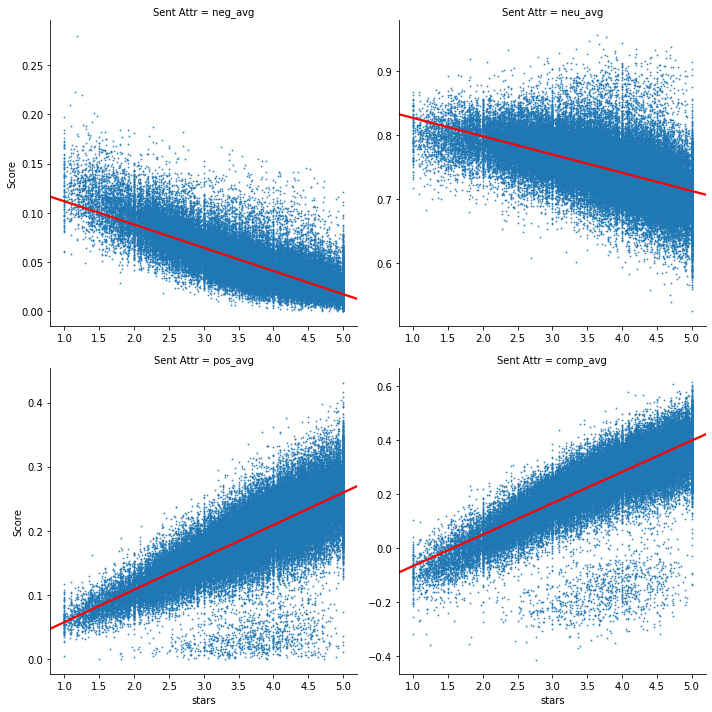

In [21]:
sns.lmplot(x='stars',y='Score',data=sentiment_avg_melt,col='Sent Attr',col_wrap=2,sharex=False,sharey=False,line_kws={'color': 'red'},scatter_kws={"s": 0.7})

Comment: The review sentiment is correlated with rating-star in a meaningful way- positive and composite sentiment increases with increasing score. The negative as well as neutral sentiment decreases with increasing star rating. This suggest that the extracted review sentiment makes sense.

**Max Sentiment**

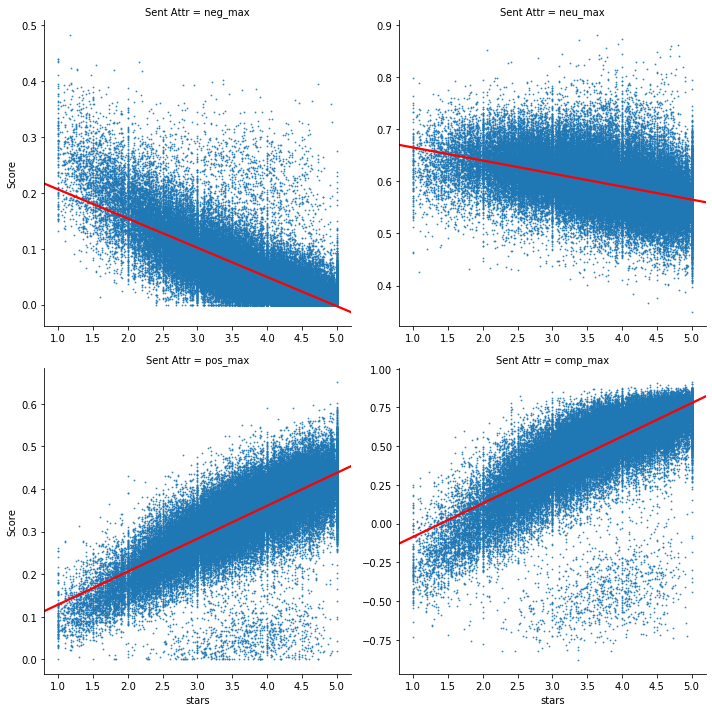

In [22]:
sns.lmplot(x='stars',y='Score',data=sentiment_max_melt,col='Sent Attr',col_wrap=2,sharex=False,sharey=False,line_kws={'color': 'red'},scatter_kws={"s": 0.7})

Comment: Again, the sentiment score based on review sentence with highest absolute compound sentiment seems tobe nicely correlated with corresponding star rating.  

## (6) Business_attributes data <a class="anchor" id="6"></a>   

This datafraim contail detailed information about businesses. It has many features, however, the data is very sparse and most of the information is missing.

In [23]:
business_attributes.head(5)

,business_id,AcceptsInsurance,ByAppointmentOnly,BusinessAcceptsCreditCards,BusinessParking_garage,BusinessParking_street,BusinessParking_validated,BusinessParking_lot,BusinessParking_valet,HairSpecializesIn_coloring,...,Corkage,DietaryRestrictions_dairy-free,DietaryRestrictions_gluten-free,DietaryRestrictions_vegan,DietaryRestrictions_kosher,DietaryRestrictions_halal,DietaryRestrictions_soy-free,DietaryRestrictions_vegetarian,AgesAllowed,RestaurantsCounterService
0,FYWN1wneV18bWNgQjJ2GNg,Na,Na,Na,True,Na,Na,Na,Na,Na,...,Na,Na,Na,Na,Na,Na,Na,Na,Na,Na
1,He-G7vWjzVUysIKrfNbPUQ,Na,Na,Na,Na,Na,Na,Na,Na,Na,...,Na,Na,Na,Na,Na,Na,Na,Na,Na,Na
2,8DShNS-LuFqpEWIp0HxijA,Na,Na,Na,Na,Na,Na,Na,Na,Na,...,Na,Na,Na,Na,Na,Na,Na,Na,Na,Na
3,PfOCPjBrlQAnz__NXj9h_w,Na,Na,Na,Na,Na,Na,Na,Na,Na,...,Na,Na,Na,Na,Na,Na,Na,Na,Na,Na
4,o9eMRCWt5PkpLDE0gOPtcQ,Na,Na,Na,Na,False,False,False,False,False,...,Na,Na,Na,Na,Na,Na,Na,Na,Na,Na


In [24]:
# Unpack string values 
business_attributes.replace({'Na': np.nan,'True':1,'False':0},inplace=True)

,Column_name,Percent_missing
business_id,business_id,0.000000
BusinessParking_street,BusinessParking_street,74.116192
BusinessParking_validated,BusinessParking_validated,74.116192
BusinessParking_valet,BusinessParking_valet,74.116192
HairSpecializesIn_coloring,HairSpecializesIn_coloring,74.116192
...,...,...
HairSpecializesIn_curly,HairSpecializesIn_curly,99.999342
HairSpecializesIn_africanamerican,HairSpecializesIn_africanamerican,99.999342
Corkage,Corkage,100.000000
DietaryRestrictions_dairy-free,DietaryRestrictions_dairy-free,100.000000


Text(0.5, 1, 'Yellow color indicates missing values')

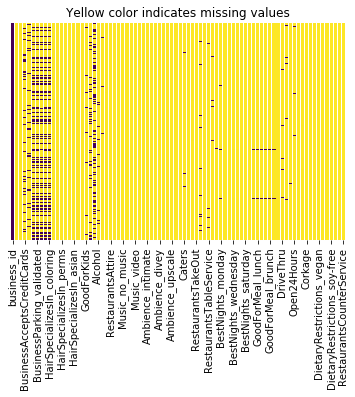

In [25]:
# business_attributes dataframe looks quite empty-check for null-values
percent_missing = business_attributes.isnull().sum() * 100 / len(business_attributes)
missing_value_df = pd.DataFrame({'Column_name': business_attributes.columns,
                                 'Percent_missing': percent_missing})
display(missing_value_df.sort_values(by=['Percent_missing']))
heat_plt=sns.heatmap(business_attributes.isnull(),yticklabels=False,cbar=False,cmap='viridis');
heat_plt.set_title('Yellow color indicates missing values')

Comment:

Although business atributes dataframe looked interesting it has to many missing values to valuable for classification IMHO.


</br> 


## (7) Data vs Target Outcomes (Business is Open or Closed) <a class="anchor" id="7"></a>
Outlook at how different features in datasets vary with the target outcome - whether business is open or closed. Here, we have looked at different features and contrasted open and closed businesses.


**Open and closed businesses vs. user rating**    
Here we contrast open and closed business using basic star rating and number of reviews averages.


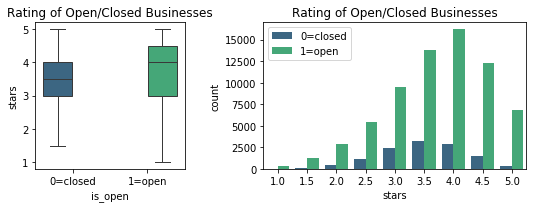

In [26]:
plt.figure(figsize=(7.5, 3))
gs = gridspec.GridSpec(1, 5)
plt.subplot(gs[0:2])
ax=sns.boxplot(x='is_open',y='stars',data=business, hue='is_open',palette='viridis',showfliers=False,linewidth=1)
plt.title('Rating of Open/Closed Businesses');
plt.tight_layout()
ax.set_xticklabels(['0=closed','1=open'])
ax.get_legend().remove()
plt.subplot(gs[2:5])
ax=sns.countplot(x='stars',data=business, hue='is_open',palette='viridis')
ax.legend(['0=closed','1=open'])
plt.title('Rating of Open/Closed Businesses');
plt.tight_layout()

Comment: It appears that open businesses have slightly higher rating, however, the differnce is not large. 

**Open and closed businesses vs. review count**

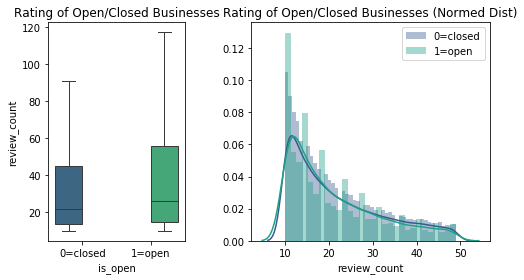

In [27]:
plt.figure(figsize=(7,4))
gs = gridspec.GridSpec(1, 5)
plt.subplot(gs[0:2])
ax=sns.boxplot(x='is_open',y='review_count',data=business, hue='is_open',palette='viridis',showfliers=False,linewidth=1)
plt.title('Rating of Open/Closed Businesses');
plt.tight_layout()
ax.set_xticklabels(['0=closed','1=open'])
ax.get_legend().remove()

plt.subplot(gs[2:6])
current_palette = sns.color_palette('viridis')
current_palette[0]
review_count_filt_close=business[(business['review_count']<50) & (business['is_open']==0)]
review_count_filt_open=business[(business['review_count']<50) & (business['is_open']==1)]
ax1=sns.distplot(review_count_filt_open['review_count'],hist=True,color=current_palette[1])
ax2=sns.distplot(review_count_filt_close['review_count'],hist=True,color=current_palette[3])
plt.legend([ax1,ax2])
plt.legend(['0=closed','1=open'])
plt.tight_layout()
plt.title('Rating of Open/Closed Businesses (Normed Dist)');


Comment:
Open business have generally more reviews than closed. However, both normalized distribution look quite similar. Does not look as very promising feature.

</br>

**Open and closed businesses vs Average review score and review count (over time)**

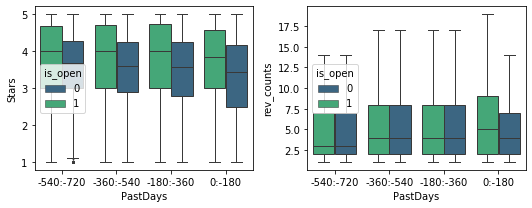

In [28]:
# Star rating vs days since last review
plt.figure(figsize=(7.5, 3))
plt.subplot(1,2,1)
star_intime_df_ext=pd.merge(star_intime_df,business[['is_open','business_id']],how='inner',on='business_id')
star_intime_df_ext_melt=star_intime_df_ext.melt(id_vars=['is_open','business_id'],var_name='PastDays',value_name='Stars')
sns.boxplot(x='PastDays',y='Stars',data=star_intime_df_ext_melt,palette='viridis',dodge=True,fliersize=1,linewidth=1,hue='is_open')
plt.tight_layout()
plt.gca().invert_xaxis()

# Review vs days since last review
plt.subplot(1,2,2)
revcount_intime_df_ext=pd.merge(revcount_intime_df,business[['is_open','business_id']],how='inner',on='business_id')
revcount_intime_df_ext_melt=revcount_intime_df_ext.melt(id_vars=['is_open','business_id'],var_name='PastDays',value_name='rev_counts')
sns.boxplot(x='PastDays',y='rev_counts',data=revcount_intime_df_ext_melt,palette='viridis',dodge=True,showfliers=False,linewidth=1,hue='is_open')
plt.tight_layout()
plt.gca().invert_xaxis()

The plot shows there are some differences in star rating and review count over time.

**Open and closed businesses vs Temporal Trend of score and # reviews**   
Here, compressed the temporal evolutions of star rating and number of reviews into single values that represents the trend of these measurements. 

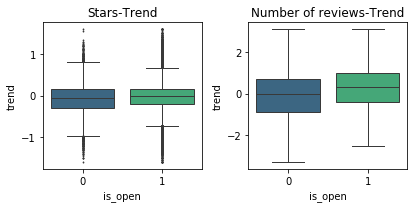

In [29]:
def calc_tmp_trend(df):
    y_vals=df.to_list() # keep only ""-xx:xx days" column
    y_vals=df.drop(['business_id', 'is_open']).to_list() # keep only ""-xx:xx days" columns
    x_vals=list(range(0,len(y_vals)))
    if ~np.isnan(y_vals).any():
        trend=-np.polyfit(x_vals,y_vals, deg=1)[0] # minus sign because the day columns are ordered newest first       
        return trend

star_intime_df_ext['trend']=star_intime_df_ext.apply(lambda df: calc_tmp_trend(df),axis=1)  
revcount_intime_df_ext['trend']=revcount_intime_df_ext.apply(lambda df: calc_tmp_trend(df),axis=1)  

plt.figure(figsize=(6, 3))
plt.subplot(1,2,1)
sns.boxplot(x='is_open',y='trend',data=star_intime_df_ext, palette='viridis',dodge=True,fliersize=1,linewidth=1)
plt.title('Stars-Trend')
plt.subplot(1,2,2)
sns.boxplot(x='is_open',y='trend',data=revcount_intime_df_ext, palette='viridis',dodge=True,fliersize=1,linewidth=1,showfliers=False)
plt.title('Number of reviews-Trend')
plt.tight_layout()


**Business Categories vs Open/Closed**   

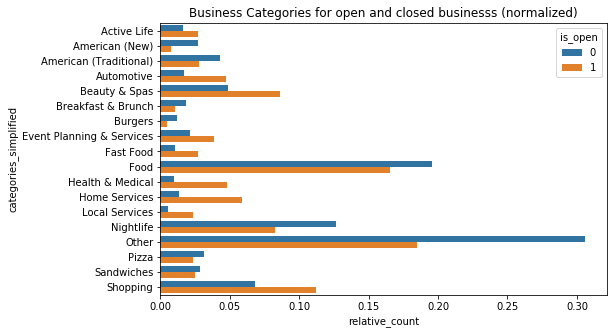

In [209]:
b_grouped=business.groupby('categories_simplified')['is_open']
b_grouped_cnts=b_grouped.value_counts()
b_grouped_cnts=pd.DataFrame(b_grouped_cnts).unstack(level=0).reset_index(drop=True)
b_grouped_cnts=b_grouped_cnts.transpose().reset_index().drop('level_0',axis=1)
b_grouped_cnts[0] = b_grouped_cnts[0].apply(lambda x: x/sum(b_grouped_cnts[0]))
b_grouped_cnts[1] = b_grouped_cnts[1].apply(lambda x: x/sum(b_grouped_cnts[1]))
b_grouped_cnts=b_grouped_cnts.melt(id_vars='categories_simplified',var_name='is_open',value_name='relative_count')

plt.figure(figsize=(8,5))
sns.barplot(y='categories_simplified',x='relative_count',hue='is_open',data=b_grouped_cnts)
plt.title('Business Categories for open and closed businesss (normalized)');

Comment: At first glance, it appears that 'other' category of businesses have much large potential to not close. Nevertheless, several other categories also separate the open and closed businesses fairly well.

**Mean Review Text Sentiment vs Open/Closed**   

We averaged the Vader review text sentiment over sentences and contrasted open and closed businesses.

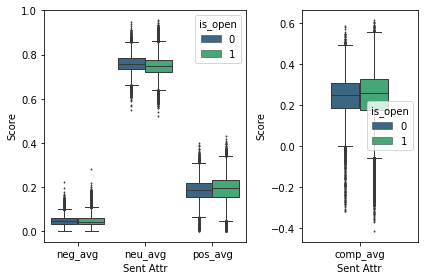

In [30]:
gs = gridspec.GridSpec(1, 5)
plt.subplot(gs[0:3])
ax=sns.boxplot(x='Sent Attr',y='Score',data=sentiment_avg_melt[sentiment_avg_melt['Sent Attr']!='comp_avg'],
               palette='viridis',dodge=True,fliersize=1,linewidth=1,hue='is_open')
plt.tight_layout()
plt.subplot(gs[3:6])
ax=sns.boxplot(x='Sent Attr',y='Score',data=sentiment_avg_melt[sentiment_avg_melt['Sent Attr']=='comp_avg'], 
               palette='viridis',dodge=True,fliersize=1,linewidth=1,width=0.5,hue='is_open')
plt.tight_layout()

**Max Sentiment vs Open/Closed**

We selected review sentence with the strongest compound sentiment and plotted the data for open and closed businesses.

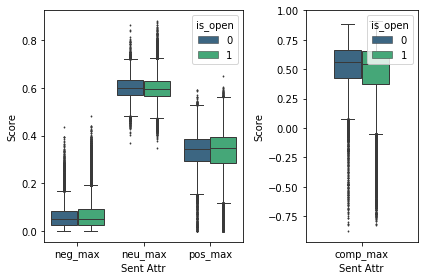

In [31]:
gs = gridspec.GridSpec(1, 5)
plt.subplot(gs[0:3])
ax=sns.boxplot(x='Sent Attr',y='Score',data=sentiment_max_melt[sentiment_max_melt['Sent Attr']!='comp_max'],
               palette='viridis',dodge=True,fliersize=1,linewidth=1,hue='is_open')
plt.tight_layout()
plt.subplot(gs[3:6])
ax=sns.boxplot(x='Sent Attr',y='Score',data=sentiment_max_melt[sentiment_max_melt['Sent Attr']=='comp_max'], 
               palette='viridis',dodge=True,fliersize=1,linewidth=1,width=0.5,hue='is_open')
plt.tight_layout()

Again, there was no apparent difference between open and closed business.

## (8) Building Classification Features Matrix <a class="anchor" id="8"></a>  

This part of code puts all the features we described into one matrix that will be later used for classification.


 

**Create feature matrix**

In [105]:
feat_mat=business[['business_id','is_open','stars','review_count']] # business 'star' and 'is_closed'
one_hot_cat = pd.get_dummies(business['categories_simplified']) # add dummies for business category
feat_mat=feat_mat.join(one_hot_cat)
feat_mat=feat_mat.merge(sentiment_grp.drop(['stars','is_open'],axis=1),how='left',on='business_id') # add sentiment columns
feat_mat=feat_mat.merge(star_intime_df_ext.drop(['is_open'],axis=1),how='left',on='business_id') # add star-temporal
feat_mat=feat_mat.merge(revcount_intime_df_ext.drop(['is_open'],axis=1),how='left',on='business_id') # add rev_count-temporal
feat_mat=feat_mat.drop(['business_id'],axis=1)
feat_mat.head()

,is_open,stars,review_count,Active Life,American (New),American (Traditional),Automotive,Beauty & Spas,Breakfast & Brunch,Burgers,...,0:-180_x,-180:-360_x,-360:-540_x,-540:-720_x,trend_x,0:-180_y,-180:-360_y,-360:-540_y,-540:-720_y,trend_y
0,1,4.0,22,0,0,0,0,0,0,0,...,3.00,5.000000,4.500000,3.00,0.0500,2,1.0,2.0,2.0,-0.1
1,1,3.0,11,0,0,0,0,1,0,0,...,3.00,NaN,2.333333,NaN,NaN,2,NaN,3.0,NaN,NaN
2,1,1.5,18,0,0,0,0,0,0,0,...,1.00,1.000000,2.600000,NaN,NaN,5,7.0,5.0,NaN,NaN
3,1,3.5,116,0,0,0,0,0,0,0,...,4.00,3.500000,3.375000,3.85,0.0575,7,8.0,8.0,20.0,-3.9
4,1,5.0,15,0,0,0,0,0,0,0,...,4.75,4.333333,NaN,5.00,NaN,4,3.0,NaN,1.0,NaN


**Drop NaN rows**

Drop rows that have missing values (mostly due to not enough reviews/businesss.

Ratio between samples:
1    0.861191
0    0.138809
Name: is_open, dtype: float64


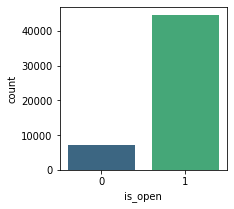

In [106]:
feat_mat_clean = feat_mat.dropna(axis = 0)
plt.figure(figsize=(3, 3))
sns.countplot(x='is_open',data=feat_mat_clean,palette='viridis')
proportion_closed=len(feat_mat_clean[feat_mat_clean['is_open']==0])/len(feat_mat_clean);
print('Ratio between samples:')
print(feat_mat_clean['is_open'].value_counts(normalize=True))

The classes are imbalanced- we have many more 'open' then 'closed' businesses. This issue will be handled below.

**Save preprocessed classification feat matrix into csv file**



In [107]:
feat_mat_clean.to_csv('feat_mat_clean.csv')

**Feature description**

In [108]:
feature_description_dict={
    'stars': 'star rating, rounded to half-stars',  
    'review_count': 'total number of reviews',
    
    'Active Life':'Active Life',
    'American (New)':'American (New)',
    'American (Traditional)':'American (Traditional)',
    'Automotive':'Automotive',      
    'Beauty & Spas':'Beauty & Spas',
    'Breakfast & Brunch':'Breakfast & Brunch',
    'Burgers':'Burgers',
    'Event Planning & Services':'Event Planning & Services',
    'Fast Food':'Fast Food',
    'Food':'Food',
    'Health & Medical':'Health & Medical',
    'Home Services':'Home Services',
    'Local Services':'Local Services',
    'Nightlife':'Nightlife',
    'Other':'Other',
    'Pizza':'Pizza',
    'Sandwiches':'Sandwiches',
    'Shopping':'Shopping',
    
    'neg_avg':'Vader: negative sentiment (sentence average)', 
    'neu_avg':'Vader: neutral sentiment (sentence average)', 
    'pos_avg':'Vader: positive sentiment (sentence average)', 
    'comp_avg':'Vader: composite sentiment (sentence average)', 
    
    'neg_max':'Vader: negative sentiment (strongest statement)',  
    'neu_max':'Vader: neutral sentiment (strongest statement)', 
    'pos_max':'Vader: negative sentiment (strongest statement)', 
    'comp_max':'Vader: composite sentiment (strongest statement)', 
    
    '0:-180_x':'star rating, past 0-180 days',
    '-180:-360_x':'star rating, past 180-360 days',
    '-360:-540_x':'star rating, past 360-540 days',
    '-540:-720_x':'star rating, past 540-720 days',
    'trend_x':'star rating, trend over past 720 days',
    
    '0:-180_y':'number or reviews, past 0-180 days',
    '-180:-360_y':'number or reviews, past 180-360 days',
    '-360:-540_y':'number or reviews, past 360-540 days',
    '-540:-720_y':'number or reviews, past 540-720 days',
    'trend_y':'number or reviews, trend over past 720 days'
    
    
}
feature_description_series=pd.Series(feature_description_dict)
feature_description_series

stars                                      star rating, rounded to half-stars
review_count                                          total number of reviews
Active Life                                                       Active Life
American (New)                                                 American (New)
American (Traditional)                                 American (Traditional)
Automotive                                                         Automotive
Beauty & Spas                                                   Beauty & Spas
Breakfast & Brunch                                         Breakfast & Brunch
Burgers                                                               Burgers
Event Planning & Services                           Event Planning & Services
Fast Food                                                           Fast Food
Food                                                                     Food
Health & Medical                                             Hea

**Save feature description into CSV**

In [109]:
feature_description_series.to_csv('feature_description.csv',header=True)

</br>  


## (9) Summary <a class="anchor" id="9"></a>
* Here, we performed Yelp dataset import followed by data exploration and classification feature extraction. This was done to prepare the data for training a prediction model that would determine whether the business will close or not. <br><br> 
* As features, we used star rating, number of reviews, businesss category as well as we extracted review text sentiment using VADER method, which is a derived measure that was not part of the original dataset. <br><br> 
* The explaratory analysis showed there is no obvious feature from the Yelp dataset that would clearly separated the open and closed business. <br><br> 
* Pre-processed and cleaned dataset was exported to 'feat_mat_clean.csv' <br><br> 